In [ ]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import accuracy_score, f1_score, classification_report
from PIL import Image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# List the files in the images directory
images_path = '/content/drive/MyDrive/Final project 2024-2025 /dataset/images'
print(os.listdir(images_path))


['01_missing_hole_02.jpg', '01_missing_hole_01.jpg', '01_missing_hole_03.jpg', '01_missing_hole_07.jpg', '01_missing_hole_04.jpg', '01_missing_hole_15.jpg', '01_missing_hole_09.jpg', '01_missing_hole_11.jpg', '01_missing_hole_14.jpg', '01_missing_hole_05.jpg', '01_missing_hole_12.jpg', '01_missing_hole_10.jpg', '01_missing_hole_20.jpg', '01_missing_hole_06.jpg', '01_missing_hole_17.jpg', '01_missing_hole_16.jpg', '01_missing_hole_08.jpg', '01_missing_hole_18.jpg', '01_missing_hole_13.jpg', '01_missing_hole_19.jpg', '04_missing_hole_08.jpg', '04_missing_hole_09.jpg', '04_missing_hole_06.jpg', '04_missing_hole_07.jpg', '04_missing_hole_04.jpg', '04_missing_hole_13.jpg', '04_missing_hole_02.jpg', '04_missing_hole_05.jpg', '04_missing_hole_14.jpg', '04_missing_hole_10.jpg', '04_missing_hole_01.jpg', '04_missing_hole_15.jpg', '04_missing_hole_11.jpg', '04_missing_hole_03.jpg', '04_missing_hole_12.jpg', '05_missing_hole_05.jpg', '06_missing_hole_04.jpg', '06_missing_hole_03.jpg', '04_missing

In [ ]:
data_dir = "/content/drive/MyDrive/Final project 2024-2025 /dataset"
images_dir = os.path.join(data_dir, "images")
annotations_dir = os.path.join(data_dir, "annotation")


In [ ]:
defect_classes = {
    1: "missing_hole",
    2: "mouse_bite",
    3: "open_circuit",
    4: "short",
    5: "spur",
    6: "spurious_copper",
}

In [ ]:
class PCBDefectDataset(Dataset):
    def __init__(self, images_dir, annotations_dir, transform=None):
        self.images_dir = images_dir
        self.annotations_dir = annotations_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(images_dir) if f.endswith(".jpg")]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image_path = os.path.join(self.images_dir, image_file)

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Load annotation
        annotation_file = image_file.replace(".jpg", ".xml")
        annotation_path = os.path.join(self.annotations_dir, annotation_file)
        tree = ET.parse(annotation_path)
        root = tree.getroot()

        # Get the defect name from the XML and map it to the integer label
        defect_name = root.find("object/name").text
        defect_type = {v: k for k, v in defect_classes.items()}  # Reverse the mapping to get the integer value
        defect_type = defect_type.get(defect_name, -1)  # Default to -1 if the name is not found

        # Convert defect_type to zero-indexed (subtract 1)
        defect_type = defect_type - 1

        if self.transform:
            image = self.transform(image)

        return image, defect_type


In [ ]:
transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize to 299x299 for Inception
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [ ]:
# Dataset and DataLoader
dataset = PCBDefectDataset(images_dir, annotations_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def train_model(model, dataloader, epochs):
    model.to(device)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # Get only the first output (logits) from Inception model
            outputs = model(images)[0]  # Extracting the main output
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        accuracy = accuracy_score(all_labels, all_preds)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}, Accuracy: {accuracy:.4f}")

    return model


In [ ]:
# Initialize models
# 1. Inception
inception_model = models.inception_v3(pretrained=True)
inception_model.fc = torch.nn.Linear(inception_model.fc.in_features, len(defect_classes))


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 185MB/s] 


In [ ]:
# 2. ConvNeXt
convnext_model = models.convnext_base(pretrained=True)
convnext_model.classifier[2] = torch.nn.Linear(convnext_model.classifier[2].in_features, len(defect_classes))

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Base_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Base_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# Train models
print("Training Inception...")
inception_model = train_model(inception_model, dataloader, epochs=5)


Training Inception...
Epoch [1/5], Loss: 81.4287, Accuracy: 0.1385
Epoch [2/5], Loss: 79.7345, Accuracy: 0.1573
Epoch [3/5], Loss: 79.6609, Accuracy: 0.1544
Epoch [4/5], Loss: 79.3372, Accuracy: 0.1558
Epoch [5/5], Loss: 79.4218, Accuracy: 0.1645


In [ ]:
# Evaluation
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=defect_classes.values()))

    return accuracy, f1

In [ ]:
print("Evaluating Inception...")
accuracy, f1 = evaluate_model(inception_model, dataloader)
print(f"Inception - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}")

Evaluating Inception...
Classification Report:
                 precision    recall  f1-score   support

   missing_hole       0.00      0.00      0.00       115
     mouse_bite       0.00      0.00      0.00       115
   open_circuit       0.00      0.00      0.00       116
          short       0.17      0.78      0.28       116
           spur       0.16      0.22      0.19       115
spurious_copper       0.00      0.00      0.00       116

       accuracy                           0.17       693
      macro avg       0.06      0.17      0.08       693
   weighted avg       0.06      0.17      0.08       693

Inception - Accuracy: 0.1674, F1 Score: 0.0774


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


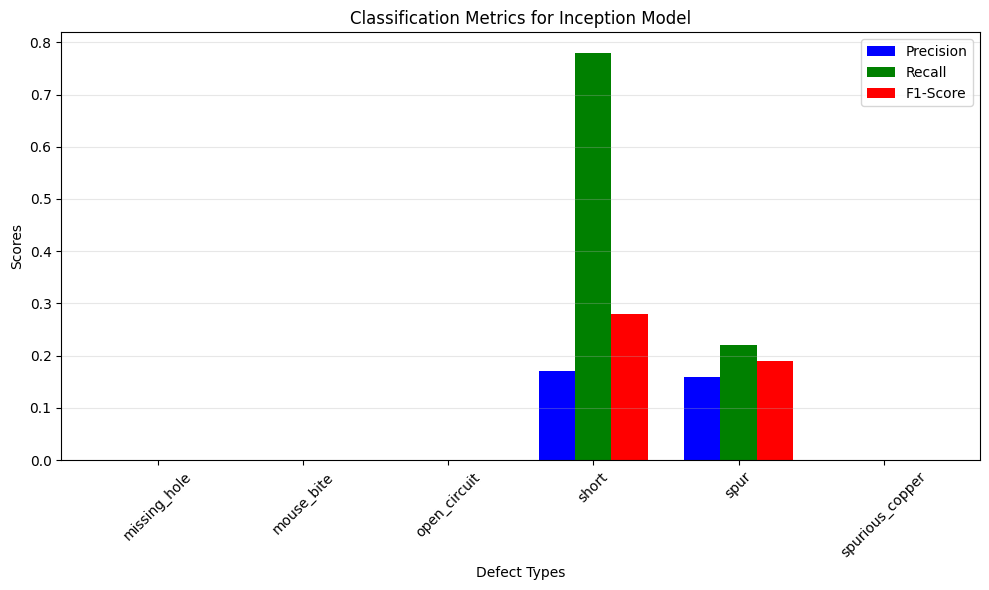

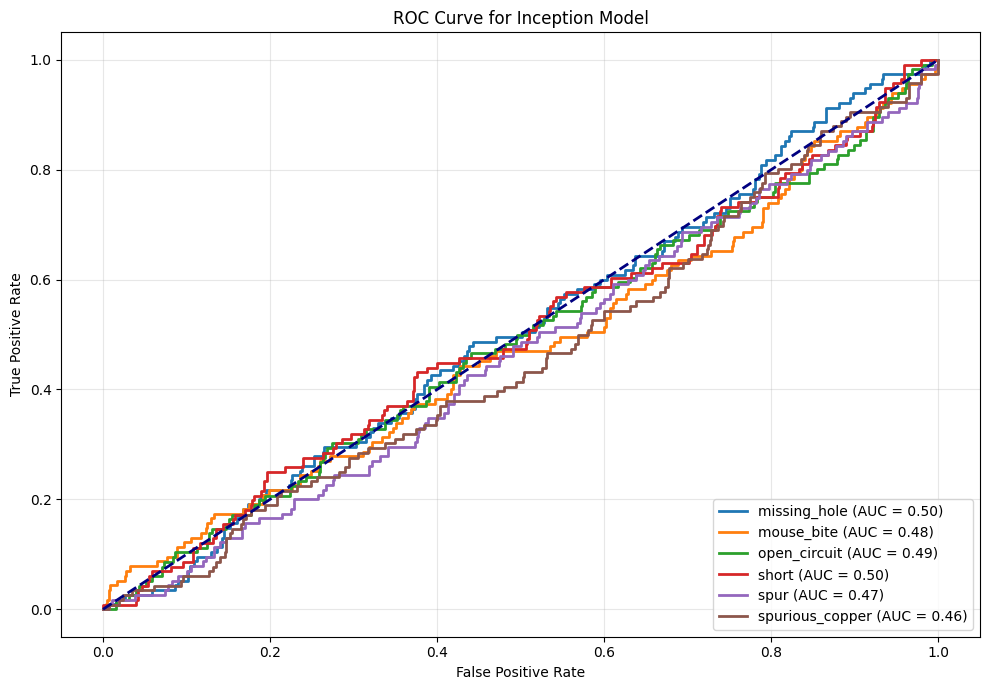

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Classification Report Data
classes = ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']
precision = [0.0, 0.0, 0.0, 0.17, 0.16, 0.0]
recall = [0.0, 0.0, 0.0, 0.78, 0.22, 0.0]
f1_score = [0.0, 0.0, 0.0, 0.28, 0.19, 0.0]
support = [115, 115, 116, 116, 115, 116]

# 1. Plot Precision, Recall, and F1-Score by Class
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='blue')
plt.bar(x, recall, width, label='Recall', color='green')
plt.bar(x + width, f1_score, width, label='F1-Score', color='red')

plt.xlabel('Defect Types')
plt.ylabel('Scores')
plt.title('Classification Metrics for Inception Model')
plt.xticks(x, classes, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Generate ROC Curve
# Simulate prediction probabilities for illustration purposes (replace with your model outputs)
y_true = np.repeat(np.arange(len(classes)), support)
y_pred_proba = np.random.rand(len(y_true), len(classes))  # Replace with actual probabilities from the model
y_true_bin = label_binarize(y_true, classes=np.arange(len(classes)))

plt.figure(figsize=(10, 7))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

# Add diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and Legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Inception Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
